### Import Libraries

In [1]:
import os
import re
import numpy as np
import pandas as pd

# Import findspark to locate the Spark installation on the system.
import findspark

# Initialise findspark so Python can find and use PySpark libraries
findspark.init() 

# Import the PySpark package to access Spark functionality
import pyspark

from pyspark.sql import SparkSession
from pyspark.sql.functions import * #col, count, trim, length, lower 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#TensorFlow Keras Libraries for Text Preprocessing and Bidirectional LSTM Model Development
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

### Startup Spark

In [2]:
spark = (
    SparkSession.builder
    .appName("VictorianAuthorLSTM")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

### Load Dataset

In [3]:
DATA_PATH = "C:\Datasets\Gungor_2018_VictorianAuthorAttribution_data-train.csv"

df_spark = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("quote", '"')
    .option("escape", '"')
    .option("encoding", "ISO-8859-1")
    .csv(DATA_PATH)
)

### Show the number of rows and schema

In [4]:
print("Number of rows:", df_spark.count())

df_spark.printSchema()

Number of rows: 19454
root
 |-- text: string (nullable = true)
 |-- author: integer (nullable = true)



### Show a few number of records

In [5]:
df_spark.select("text", "author").show(10)

+--------------------+------+
|                text|author|
+--------------------+------+
|ou have time to l...|     1|
|wish for solitude...|     1|
|and the skirt ble...|     1|
|of san and the ro...|     1|
|an hour s walk wa...|     1|
|on the comfortabl...|     1|
|on account of his...|     1|
|at any rate whate...|     1|
|date with the inf...|     1|
|accept such figur...|     1|
+--------------------+------+
only showing top 10 rows


### Group and Count the number of authors

In [6]:
author_counts = (
    df_spark
    .groupBy("author")
    .count()
    .orderBy("author")
)

author_counts.show(50)

+------+-----+
|author|count|
+------+-----+
|     1|  299|
|     2|  382|
|     3|  213|
|     4|  447|
|     8| 1285|
|     9|  263|
|    10|  755|
|    11|  383|
|    12|  233|
|    13|  485|
|    14|  111|
|    15|  492|
|    16|  183|
|    17|  660|
|    19|  736|
|    20|  587|
|    21|  369|
|    22|  495|
|    23|  455|
|    24|  380|
|    25| 1159|
|    26|  422|
|    27|  208|
|    28|  314|
|    29|  645|
|    32|  703|
|    33|  346|
|    34|  453|
|    35|  659|
|    36|  457|
|    37|  674|
|    39|  413|
|    41|  260|
|    42|  143|
|    43|  640|
|    44|  468|
|    45|   29|
|    46|  247|
|    48| 1087|
|    50|  914|
+------+-----+



### Graphical Presentation of Authors

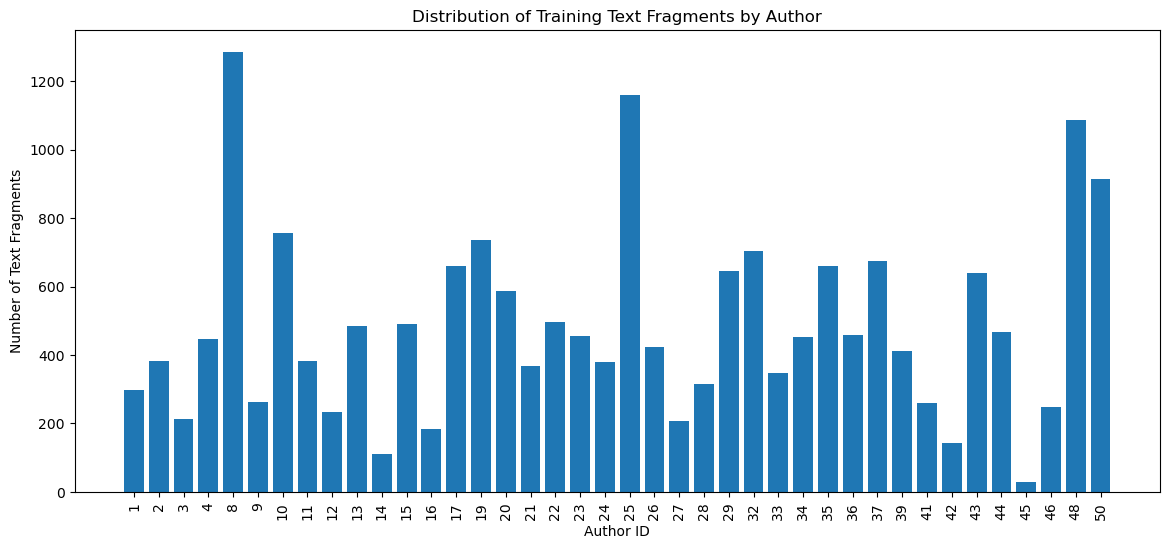

In [7]:
author_counts_pd = author_counts.toPandas()

plt.figure(figsize=(14, 6))

plt.bar(
    author_counts_pd["author"].astype(str),
    author_counts_pd["count"]
)

plt.xlabel("Author ID")
plt.ylabel("Number of Text Fragments")
plt.title("Distribution of Training Text Fragments by Author")
plt.xticks(rotation=90)

plt.show()

### View a few records and cut the display to show only 200 characters

In [8]:
df_spark.select(
    "author",
    "text"
).show(
    5,
    truncate=200
)

+------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|author|                                                                                                                                                                                                    text|
+------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|     1|ou have time to listen i will give you the entire story he said it may form the basis of a future novel and prove quite as interesting as one of your own invention i had the time to listen of cours...|
|     1|wish for solitude he was twenty years of age and in the possession of perfect health most youths like him would have the stillness of the and welcomed j

### Clean text using PySpark

In [9]:
#from pyspark.sql.functions import lower
df_clean = (
    df_spark
    .withColumn(
        "clean_text",
        lower(col("text"))
    )
    .withColumn(
        "clean_text",
        regexp_replace(
            col("clean_text"),
            r"[^a-z\s]",
            " "
        )
    )
    .withColumn(
        "clean_text",
        regexp_replace(
            col("clean_text"),
            r"\s+",
            " "
        )
    )
    .withColumn(
        "clean_text",
        trim(col("clean_text"))
    )
)

### Randomly select a Maximum number of Samples (500) per author and delete the null rows

In [10]:
from pyspark.sql import Window
from pyspark.sql.functions import row_number, rand, col

SAMPLES_PER_AUTHOR = 500

window_by_author = Window.partitionBy("author").orderBy(rand(seed=42))

df_sample = (
    df_clean
    .filter(col("author").isNotNull() & col("clean_text").isNotNull())
    .withColumn("row_num", row_number().over(window_by_author))
    .filter(col("row_num") <= SAMPLES_PER_AUTHOR)
    .drop("row_num")
)

print("Balanced sample size:", df_sample.count())
print("Number of authors:", df_sample.select("author").distinct().count())

df_sample.groupBy("author").count().orderBy("author").show(50)

Balanced sample size: 15450
Number of authors: 40
+------+-----+
|author|count|
+------+-----+
|     1|  299|
|     2|  382|
|     3|  213|
|     4|  447|
|     8|  500|
|     9|  263|
|    10|  500|
|    11|  383|
|    12|  233|
|    13|  485|
|    14|  111|
|    15|  492|
|    16|  183|
|    17|  500|
|    19|  500|
|    20|  500|
|    21|  369|
|    22|  495|
|    23|  455|
|    24|  380|
|    25|  500|
|    26|  422|
|    27|  208|
|    28|  314|
|    29|  500|
|    32|  500|
|    33|  346|
|    34|  453|
|    35|  500|
|    36|  457|
|    37|  500|
|    39|  413|
|    41|  260|
|    42|  143|
|    43|  500|
|    44|  468|
|    45|   29|
|    46|  247|
|    48|  500|
|    50|  500|
+------+-----+



### Convert Spark data to Pandas and show the chart after text sample limit was set to 500
  *The reason for converting to Pandas is that TensorFlow/Keras will be used to train the LSTM*

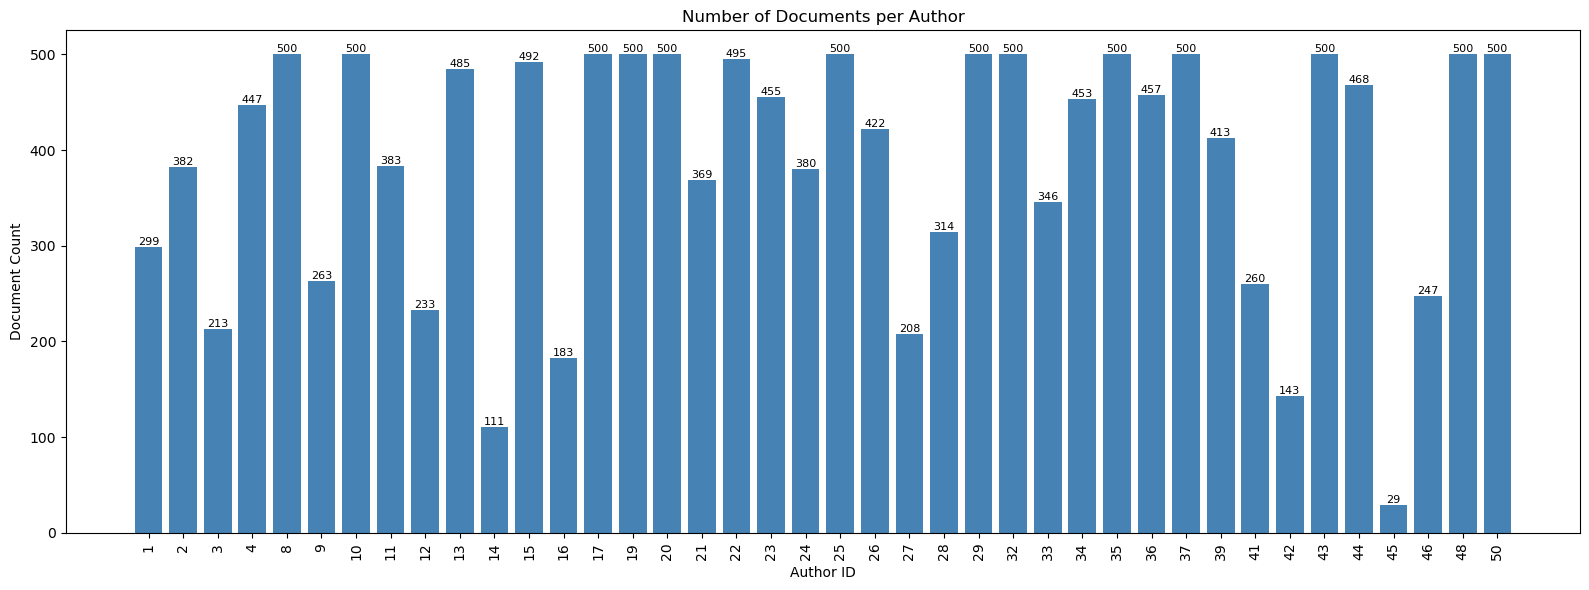

In [11]:
pdf = (
    df_sample
    .select("author", "clean_text")
    .toPandas()
)

pdf = pdf.dropna(subset=["author", "clean_text"]).reset_index(drop=True)

# Count documents per author
author_counts = (
    pdf["author"]
    .value_counts()
    .sort_index()
)

# Plot
plt.figure(figsize=(16, 6))
bars = plt.bar(
    author_counts.index.astype(str),
    author_counts.values,
    color="steelblue"
)

plt.title("Number of Documents per Author")
plt.xlabel("Author ID")
plt.ylabel("Document Count")

# Show all author IDs on x-axis
plt.xticks(
    ticks=range(len(author_counts)),
    labels=author_counts.index.astype(str),
    rotation=90
)

# Show count value above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Check for duplicates in case they were missed by spark

In [12]:
print(pdf.duplicated())

0        False
1        False
2        False
3        False
4        False
         ...  
15445    False
15446    False
15447    False
15448    False
15449    False
Length: 15450, dtype: bool


### Split the Data into Training and Test Data

In [13]:
X_text_train, X_text_test, y_train_raw, y_test_raw = train_test_split(
    pdf["clean_text"].values,
    pdf["author"].values,
    test_size=0.20,
    random_state=42,
    stratify=pdf["author"].values   #ensures that the train and test sets have approximately the same distribution of authors as the original dataset
)

print("Training texts:", len(X_text_train))
print("Testing texts:", len(X_text_test))

Training texts: 12360
Testing texts: 3090


### Encode the authors

In [14]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

NUM_CLASSES = len(label_encoder.classes_)

print("Number of authors:", NUM_CLASSES)
print("Number of classes:", label_encoder.classes_)

Number of authors: 40
Number of classes: [ 1  2  3  4  8  9 10 11 12 13 14 15 16 17 19 20 21 22 23 24 25 26 27 28
 29 32 33 34 35 36 37 39 41 42 43 44 45 46 48 50]


### Tokenise

In [15]:
MAX_WORDS = 30000
MAX_SEQUENCE_LENGTH = 500    # Set to this number to reduce CPU and Memory issues when model is created

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<TTT>",
    filters=""
)

tokenizer.fit_on_texts(X_text_train)

X_train = pad_sequences(
    tokenizer.texts_to_sequences(X_text_train),
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    tokenizer.texts_to_sequences(X_text_test),
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Vocabulary learned from training data:", len(tokenizer.word_index))

X_train shape: (12360, 500)
X_test shape: (3090, 500)
Vocabulary learned from training data: 9978


### Bidirectional LSTM Architecture

In [16]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, SpatialDropout1D
from tensorflow.keras.models import Sequential

model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=160,
        mask_zero=True
    ),

    SpatialDropout1D(0.20),

    Bidirectional(
        LSTM(
            160,
            return_sequences=False,
            dropout=0.25
        )
    ),

    Dense(128, activation="relu"),
    Dropout(0.40),

    Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 500, 160)            │       4,800,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 500, 160)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 320)                 │         410,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 40)                  │           5,160 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,257,128 (20.05 MB)

 Trainable params: 5,257,128 (20.05 MB)

 Non-trainable params: 0 (0.00 B)

### Build Long Short-Term Memory Recurrent Neural Network

In [17]:
NUM_CLASSES = len(
    label_encoder.classes_
)

model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=False,
            dropout=0.2
        )
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

## Compile the Model
*The learning rate is set to 0.0005 and gradient clipping is enabled. This is intended to make training more stable on the larger model.*

In [18]:
optimizer = Adam(
    learning_rate=0.0005,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train the Model

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - accuracy: 0.0299 - loss: 3.6714 - val_accuracy: 0.0311 - val_loss: 3.6327 - learning_rate: 5.0000e-04
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 318s 4s/step - accuracy: 0.0336 - loss: 3.6148 - val_accuracy: 0.0619 - val_loss: 3.5485 - learning_rate: 5.0000e-04
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 334s 4s/step - accuracy: 0.0607 - loss: 3.4796 - val_accuracy: 0.0663 - val_loss: 3.3954 - learning_rate: 5.0000e-04
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.0852 - loss: 3.1742 - val_accuracy: 0.0890 - val_loss: 3.1472 - learning_rate: 2.5000e-04
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.0886 - loss: 3.0805 - val_accuracy: 0.0979 - val_loss: 3.1078 - learning_rate: 2.5000e-04
Epoch 8/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.0975 - loss: 3.0162 - val_accuracy: 0.0983 - val_loss: 3.0593 - learning_rate: 2.5000e-04
Epoch 9/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.1084 

### Accuracy Plot

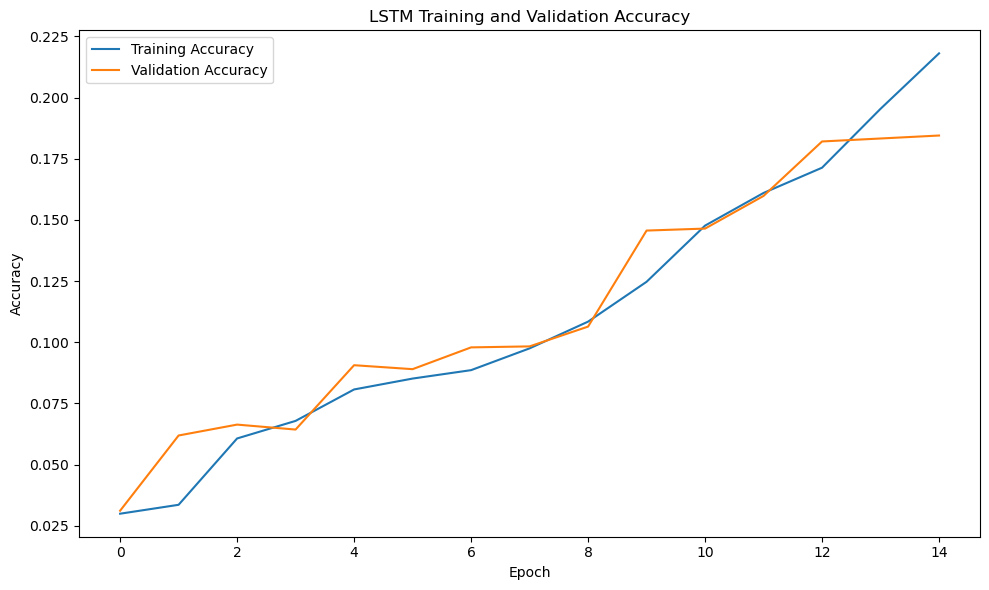

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "LSTM Training and Validation Accuracy"
)

plt.legend()

plt.tight_layout()

plt.show()

### Plot Loss

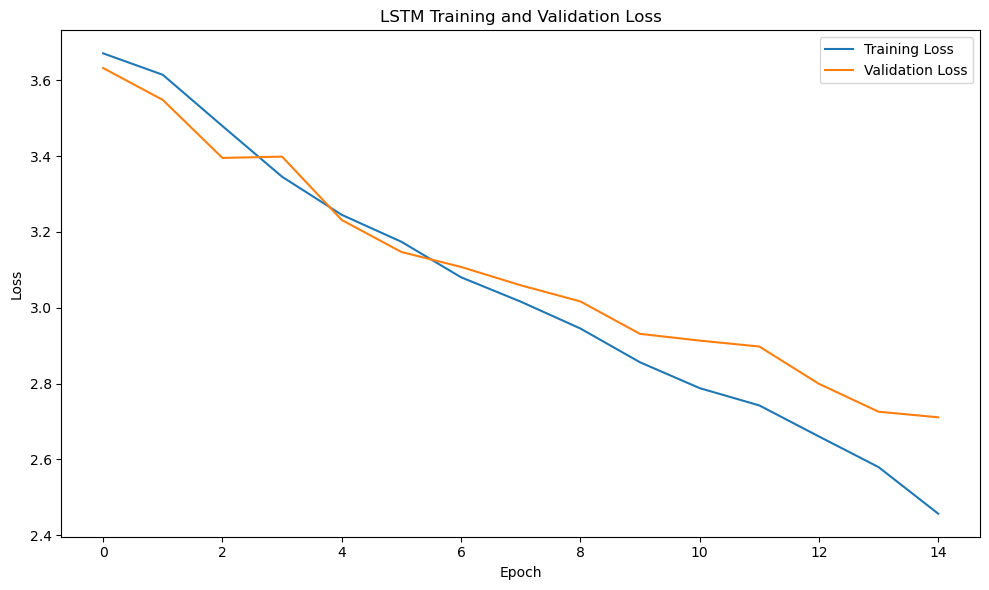

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "LSTM Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.show()

### Evaluate LSTM model

In [22]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Loss: 2.7284
Test Accuracy: 0.1958
Test Accuracy: 19.58%


### LSTM Evaluation

In [23]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Loss: 2.7284
Test Accuracy: 0.1958
Test Accuracy: 19.58%


### Generate Prediction for Re-Trained model

In [24]:
probabilities = model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    probabilities,
    axis=1
)

### Precision, recall and F1-score

In [25]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            str(x)
            for x in label_encoder.classes_
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        60
           2       0.00      0.00      0.00        76
           3       0.00      0.00      0.00        43
           4       0.11      0.10      0.10        89
           8       0.00      0.00      0.00       100
           9       0.00      0.00      0.00        53
          10       0.05      0.01      0.02       100
          11       0.00      0.00      0.00        76
          12       0.00      0.00      0.00        47
          13       0.27      0.58      0.37        97
          14       0.00      0.00      0.00        22
          15       0.12      0.21      0.15        98
          16       0.00      0.00      0.00        37
          17       0.10      0.12      0.11       100
          19       0.23      0.80      0.35       100
          20       0.11      0.04      0.06       100
          21       0.00      0.00      0.00        74
          22       0.50    

# ReTraining

### Retraining LSTM Architecture

In [26]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, SpatialDropout1D
from tensorflow.keras.models import Sequential

model_retr = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=160,
        mask_zero=True
    ),

    SpatialDropout1D(0.20),

    Bidirectional(
        LSTM(
            160,
            return_sequences=False,
            dropout=0.25
        )
    ),

    Dense(128, activation="relu"),
    Dropout(0.40),

    Dense(NUM_CLASSES, activation="softmax")
])


### Recompile Model

In [27]:
optimizer = Adam(
    learning_rate=0.0005,
    clipnorm=1.0
)

model_retr.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Actual Model Retraining

In [28]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_retr = model_retr.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 727s 9s/step - accuracy: 0.0320 - loss: 3.6575 - val_accuracy: 0.0287 - val_loss: 3.6180 - learning_rate: 5.0000e-04
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 791s 10s/step - accuracy: 0.0746 - loss: 3.3127 - val_accuracy: 0.0712 - val_loss: 3.3277 - learning_rate: 5.0000e-04
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 790s 10s/step - accuracy: 0.0866 - loss: 3.2121 - val_accuracy: 0.0874 - val_loss: 3.1832 - learning_rate: 5.0000e-04
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 790s 10s/step - accuracy: 0.1448 - loss: 2.8280 - val_accuracy: 0.1299 - val_loss: 3.0694 - learning_rate: 5.0000e-04
Epoch 9/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 801s 10s/step - accuracy: 0.1761 - loss: 2.6888 - val_accuracy: 0.1683 - val_loss: 2.8988 - learning_rate: 5.0000e-04
Epoch 10/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 821s 11s/step - accuracy: 0.2162 - loss: 2.5447 - val_accuracy: 0.1739 - val_loss: 2.8797 - learning_rate: 5.0000e-04
Epoch 11/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 821s 11s/step - accuracy:

### Retrained Model Accuracy Plot

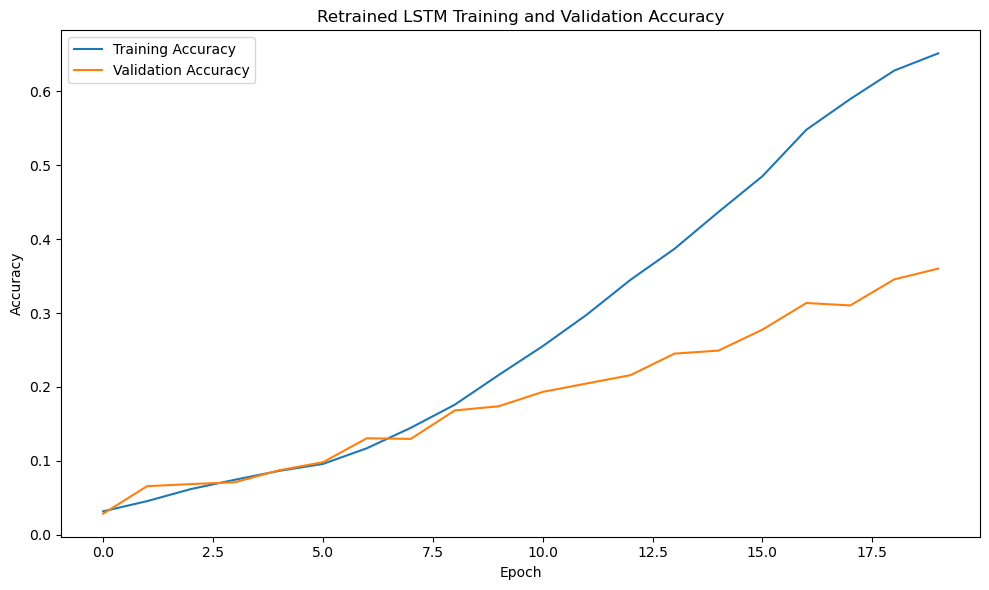

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_retr.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_retr.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Retrained LSTM Training and Validation Accuracy"
)

plt.legend()

plt.tight_layout()

plt.show()

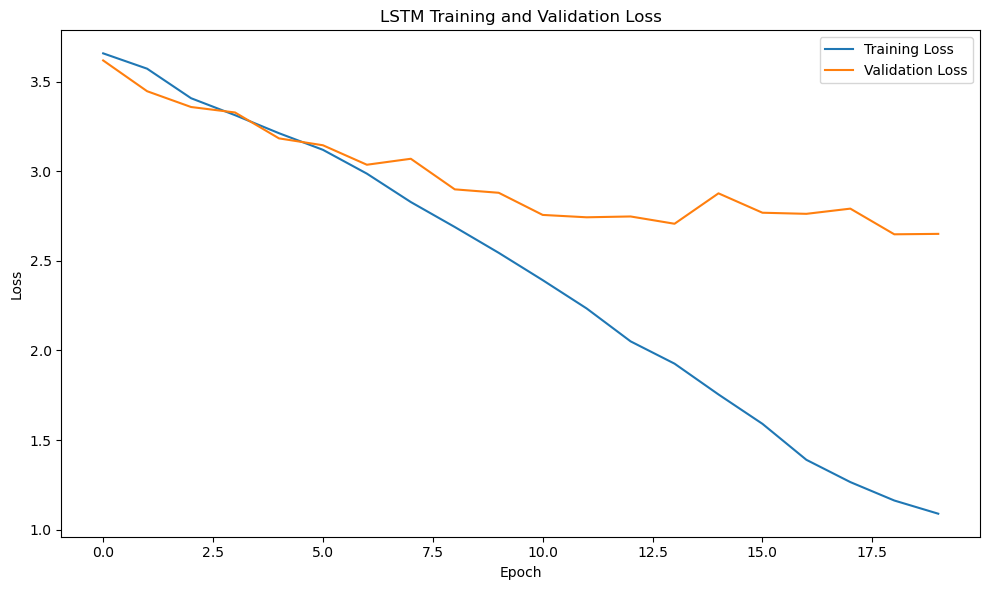

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_retr.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_retr.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "LSTM Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.show()

### Re-trained LSTM Evaluation

In [31]:
test_loss, test_accuracy = model_retr.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Loss: 2.6774
Test Accuracy: 0.3298
Test Accuracy: 32.98%


### Generate Prediction for Re-Trained model

In [32]:
probabilities = model_retr.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    probabilities,
    axis=1
)

### Precision, recall and F1-score

In [33]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            str(x)
            for x in label_encoder.classes_
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1       0.30      0.18      0.23        60
           2       0.12      0.09      0.11        76
           3       0.06      0.02      0.03        43
           4       0.23      0.27      0.25        89
           8       0.09      0.09      0.09       100
           9       0.19      0.13      0.16        53
          10       0.34      0.43      0.38       100
          11       0.38      0.11      0.16        76
          12       0.20      0.11      0.14        47
          13       0.45      0.38      0.41        97
          14       0.00      0.00      0.00        22
          15       0.33      0.34      0.34        98
          16       0.08      0.03      0.04        37
          17       0.18      0.27      0.21       100
          19       0.73      0.47      0.57       100
          20       0.59      0.71      0.64       100
          21       0.23      0.12      0.16        74
          22       0.65    

# Create the Bot

In [34]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

### Create a function to predict an Author

In [39]:
def predict_author(text):
    
    # Clean input
    cleaned = clean_text(text)
    
    # Convert words to numerical sequence
    sequence = tokenizer.texts_to_sequences(
        [cleaned]
    )
    
    # Pad sequence
    padded = pad_sequences(
        sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )
    
    # Predict
    probabilities = model_retr.predict(
        padded,
        verbose=0
    )[0]
    
    # Get best prediction
    predicted_index = np.argmax(
        probabilities
    )
    
    predicted_author = label_encoder.inverse_transform(
        [predicted_index]
    )[0]

    confidence = probabilities[predicted_index]
    
    return predicted_author, confidence

### Bot Input Prompt

In [42]:
print("Enter text (press Enter twice to finish):")

lines = []

while True:
    line = input()
    if line == "":
        break
    lines.append(line)

text = "\n".join(lines)

def predict_top_authors(text, top_n=5):
    cleaned = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    cleaned = re.sub(r"\s+", " ", cleaned).strip()

    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    probs = model_retr.predict(padded, verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:top_n]

    results = pd.DataFrame({
        "Rank": range(1, top_n + 1),
        "Author": label_encoder.inverse_transform(top_indices),
        "Probability": probs[top_indices]
    })

    results["Probability"] = results["Probability"].map(
        lambda x: f"{x:.2%}"
    )

    return results

sample_text = text

predict_top_authors(sample_text)

Enter text (press Enter twice to finish):


 property on all sides with a strong guard then extend your lines outward in the direction of the houses from which the apparatus would undoubtedly be worked get a warrant and thoroughly search all of the premises nearest the mills act as if you mean business and my word for it you will have this thing uncovered before the sun sets smiled at the of the agent that might work and again it might not said he l f has really been placed under the other mills and is to be exploded with an apparatus it is more likely to be connected with some house a mile away than with one nearer this strike has been going on for weeks and the have had every chance we must their claws by a little pretended â t tell you before we can hope to get them into our net agent baker had just begun to say they shall never â when another visitor was announced it was president who had read an account of the trouble in the newspaper and taken the first train from his home for he looked much worried and listened carefully 

,Rank,Author,Probability
0,1,39,16.88%
1,2,4,14.59%
2,3,21,12.51%
3,4,16,12.08%
4,5,9,7.42%
